# Лабораторная работа №5: Градиентный бустинг + Итоги (ЛР №1–5)

**Датасеты** (те же, что в ЛР №1–4):
- **Классификация:** [Body Performance Data](https://www.kaggle.com/datasets/kukuroo3/body-performance-data)
- **Регрессия:** [House Price Data](https://www.kaggle.com/datasets/shubhammeshram579/house)


In [1]:
# Импорт библиотек
# sklearn.ensemble — GradientBoosting, RandomForest, а также базовые алгоритмы для финального сравнения
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import glob
from collections import Counter
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier, GradientBoostingRegressor,
    RandomForestClassifier, RandomForestRegressor
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, r2_score
)

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
np.random.seed(42)
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


In [2]:
# Загрузка датасетов через kagglehub
# kagglehub кэширует датасет локально после первой загрузки
classification_dataset = kagglehub.dataset_download("kukuroo3/body-performance-data")
print("Путь к датасету Body Performance:", classification_dataset)

regression_dataset = kagglehub.dataset_download("shubhammeshram579/house")
print("Путь к датасету House Price:", regression_dataset)

100%|██████████| 249k/249k [00:00<00:00, 787kB/s]

Extracting files...


Путь к датасету Body Performance: /root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15


100%|██████████| 11.6k/11.6k [00:00<00:00, 22.6MB/s]

Extracting files...
Путь к датасету House Price: /root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1


In [3]:
# Поиск CSV-файлов в скачанных директориях и загрузка датафреймов
cls_files = glob.glob(os.path.join(classification_dataset, '**', '*.csv'), recursive=True)
reg_files = glob.glob(os.path.join(regression_dataset, '**', '*.csv'), recursive=True)

print('Файлы классификации:', cls_files)
print('Файлы регрессии:', reg_files)

# Загружаем первый найденный CSV для каждой задачи
df_cls = pd.read_csv(cls_files[0])
df_reg = pd.read_csv(reg_files[0])

print(f'\nДатасет классификации: {df_cls.shape[0]} строк, {df_cls.shape[1]} столбцов')
print(f'Датасет регрессии: {df_reg.shape[0]} строк, {df_reg.shape[1]} столбцов')

Файлы классификации: ['/root/.cache/kagglehub/datasets/kukuroo3/body-performance-data/versions/15/bodyPerformance.csv']
Файлы регрессии: ['/root/.cache/kagglehub/datasets/shubhammeshram579/house/versions/1/Housing.csv']

Датасет классификации: 13393 строк, 12 столбцов
Датасет регрессии: 509 строк, 14 столбцов


## Подготовка данных

Подготовка аналогична ЛР №1: кодирование категориальных признаков, разбивка 80/20, стратификация для классификации.

In [4]:
# ── КЛАССИФИКАЦИЯ: предобработка ──────────────────────────────────────────────
# Кодируем категориальные признаки (пол и целевой класс) числовыми значениями,
# так как sklearn-модели работают только с числовыми данными

df_cls_clean = df_cls.copy()

class_col = 'class'

if 'gender' in df_cls_clean.columns:
    df_cls_clean['gender'] = LabelEncoder().fit_transform(df_cls_clean['gender'])

le_cls = LabelEncoder()
df_cls_clean[class_col] = le_cls.fit_transform(df_cls_clean[class_col])

X_cls = df_cls_clean.drop(columns=[class_col])
y_cls = df_cls_clean[class_col]

# Стратификация сохраняет пропорции классов в train/test
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

print(f'Классификация → train: {X_cls_train.shape[0]}, test: {X_cls_test.shape[0]}')
print(f'Признаки: {list(X_cls.columns)}')

Классификация → train: 10714, test: 2679
Признаки: ['age', 'gender', 'height_cm', 'weight_kg', 'body fat_%', 'diastolic', 'systolic', 'gripForce', 'sit and bend forward_cm', 'sit-ups counts', 'broad jump_cm']


In [5]:
# ── РЕГРЕССИЯ: предобработка ──────────────────────────────────────────────────
# Оставляем только числовые столбцы и удаляем строки с пропусками

price_col = 'MEDV'

df_reg_clean = df_reg.select_dtypes(include=[np.number]).dropna().copy()

X_reg = df_reg_clean.drop(columns=[price_col])
y_reg = df_reg_clean[price_col]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f'Регрессия → train: {X_reg_train.shape[0]}, test: {X_reg_test.shape[0]}')
print(f'Признаки: {list(X_reg.columns)}')

Регрессия → train: 400, test: 101
Признаки: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


---
## 2. Базовый бейзлайн (sklearn, дефолтные параметры)

Базовый GradientBoosting: 100 деревьев глубиной 3, `learning_rate=0.1`. Даже без настройки бустинг, как правило, превосходит одиночное дерево и сопоставим с Random Forest, однако чувствителен к переобучению при большом числе итераций.

In [6]:
# 2a. Базовый GradientBoostingClassifier
# Стратегия OvR (One-vs-Rest): для K классов строится K независимых бинарных бустингов
# loss='log_loss' — кросс-энтропия, подходит для многоклассовой классификации

gb_cls_base = GradientBoostingClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    random_state=42
)
gb_cls_base.fit(X_cls_train, y_cls_train)

y_cls_pred_base       = gb_cls_base.predict(X_cls_test)
y_cls_pred_base_train = gb_cls_base.predict(X_cls_train)

acc_gb_base       = accuracy_score(y_cls_test,  y_cls_pred_base)
acc_gb_base_train = accuracy_score(y_cls_train, y_cls_pred_base_train)
f1_gb_base        = f1_score(y_cls_test,  y_cls_pred_base,       average='macro')
f1_gb_base_train  = f1_score(y_cls_train, y_cls_pred_base_train, average='macro')

print('=== БАЗОВЫЙ GradientBoostingClassifier (sklearn) ===')
print(f'Train Accuracy: {acc_gb_base_train:.4f}  |  Train F1: {f1_gb_base_train:.4f}')
print(f'Test  Accuracy: {acc_gb_base:.4f}  |  Test  F1: {f1_gb_base:.4f}')
print(f'Разрыв train/test Accuracy: {acc_gb_base_train - acc_gb_base:.4f}')
print()
print('Подробный отчёт (test):')
print(classification_report(y_cls_test, y_cls_pred_base, target_names=le_cls.classes_))

=== БАЗОВЫЙ GradientBoostingClassifier (sklearn) ===
Train Accuracy: 0.7702  |  Train F1: 0.7698
Test  Accuracy: 0.7290  |  Test  F1: 0.7280
Разрыв train/test Accuracy: 0.0412

Подробный отчёт (test):
              precision    recall  f1-score   support

           A       0.69      0.88      0.77       670
           B       0.60      0.59      0.59       669
           C       0.74      0.62      0.67       670
           D       0.93      0.83      0.87       670

    accuracy                           0.73      2679
   macro avg       0.74      0.73      0.73      2679
weighted avg       0.74      0.73      0.73      2679



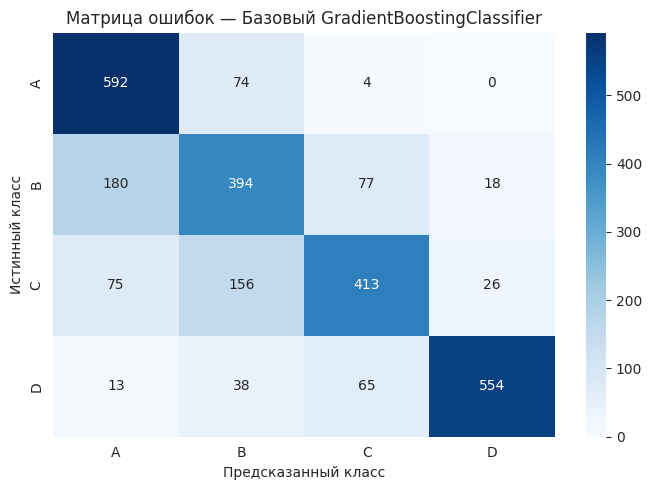

In [7]:
# Матрица ошибок базового классификатора

cm_base = confusion_matrix(y_cls_test, y_cls_pred_base)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cls.classes_, yticklabels=le_cls.classes_)
plt.title('Матрица ошибок — Базовый GradientBoostingClassifier')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

In [8]:
# 2b. Базовый GradientBoostingRegressor
# loss='squared_error' — MSE-потери, стандарт для регрессии

gb_reg_base = GradientBoostingRegressor(
    n_estimators=100, learning_rate=0.1, max_depth=3,
    random_state=42
)
gb_reg_base.fit(X_reg_train, y_reg_train)

y_reg_pred_base       = gb_reg_base.predict(X_reg_test)
y_reg_pred_base_train = gb_reg_base.predict(X_reg_train)

mae_gb_base   = mean_absolute_error(y_reg_test,  y_reg_pred_base)
rmse_gb_base  = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_base))
r2_gb_base    = r2_score(y_reg_test,  y_reg_pred_base)
r2_gb_base_tr = r2_score(y_reg_train, y_reg_pred_base_train)

print('=== БАЗОВЫЙ GradientBoostingRegressor (sklearn) ===')
print(f'Train R²:   {r2_gb_base_tr:.4f}')
print(f'Test  MAE:  {mae_gb_base:.2f}')
print(f'Test  RMSE: {rmse_gb_base:.2f}')
print(f'Test  R²:   {r2_gb_base:.4f}')

=== БАЗОВЫЙ GradientBoostingRegressor (sklearn) ===
Train R²:   0.9787
Test  MAE:  2.23
Test  RMSE: 3.62
Test  R²:   0.8373


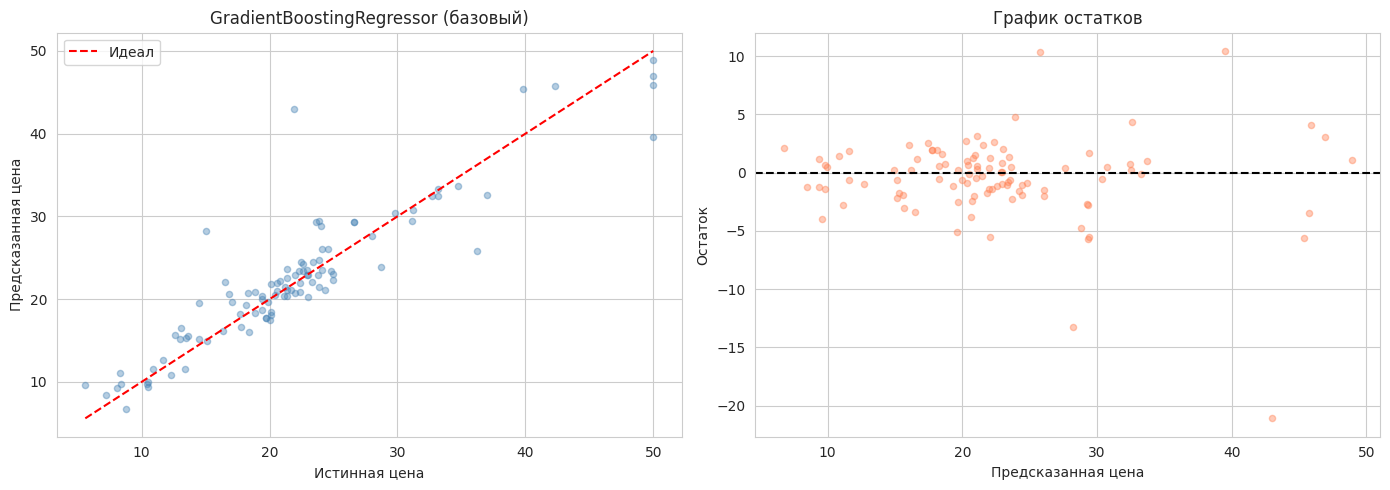

In [9]:
# Визуализация предсказаний базового регрессора

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_reg_test, y_reg_pred_base, alpha=0.4, s=20, color='steelblue')
lims = [min(y_reg_test.min(), y_reg_pred_base.min()),
        max(y_reg_test.max(), y_reg_pred_base.max())]
axes[0].plot(lims, lims, 'r--', label='Идеал')
axes[0].set_xlabel('Истинная цена')
axes[0].set_ylabel('Предсказанная цена')
axes[0].set_title('GradientBoostingRegressor (базовый)')
axes[0].legend()

residuals = y_reg_test - y_reg_pred_base
axes[1].scatter(y_reg_pred_base, residuals, alpha=0.4, s=20, color='coral')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Предсказанная цена')
axes[1].set_ylabel('Остаток')
axes[1].set_title('График остатков')
plt.tight_layout()
plt.show()

---
## 3. Улучшение бейзлайна

In [10]:
# Гипотеза 1: Early stopping через staged_predict
# staged_predict возвращает итератор предсказаний после каждого дерева,
# позволяя найти оптимальное число итераций без повторного обучения

gb_staged_cls = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)
gb_staged_cls.fit(X_cls_train, y_cls_train)

# Вычисляем F1 после каждого дерева на test
staged_f1 = [
    f1_score(y_cls_test, pred, average='macro')
    for pred in gb_staged_cls.staged_predict(X_cls_test)
]
best_iter_cls = np.argmax(staged_f1) + 1
print(f'Оптимальное число итераций (классификация): {best_iter_cls}  → F1={max(staged_f1):.4f}')

gb_staged_reg = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, random_state=42
)
gb_staged_reg.fit(X_reg_train, y_reg_train)

staged_r2 = [
    r2_score(y_reg_test, pred)
    for pred in gb_staged_reg.staged_predict(X_reg_test)
]
best_iter_reg = np.argmax(staged_r2) + 1
print(f'Оптимальное число итераций (регрессия):     {best_iter_reg}  → R²={max(staged_r2):.4f}')

Оптимальное число итераций (классификация): 291  → F1=0.7450
Оптимальное число итераций (регрессия):     133  → R²=0.8380


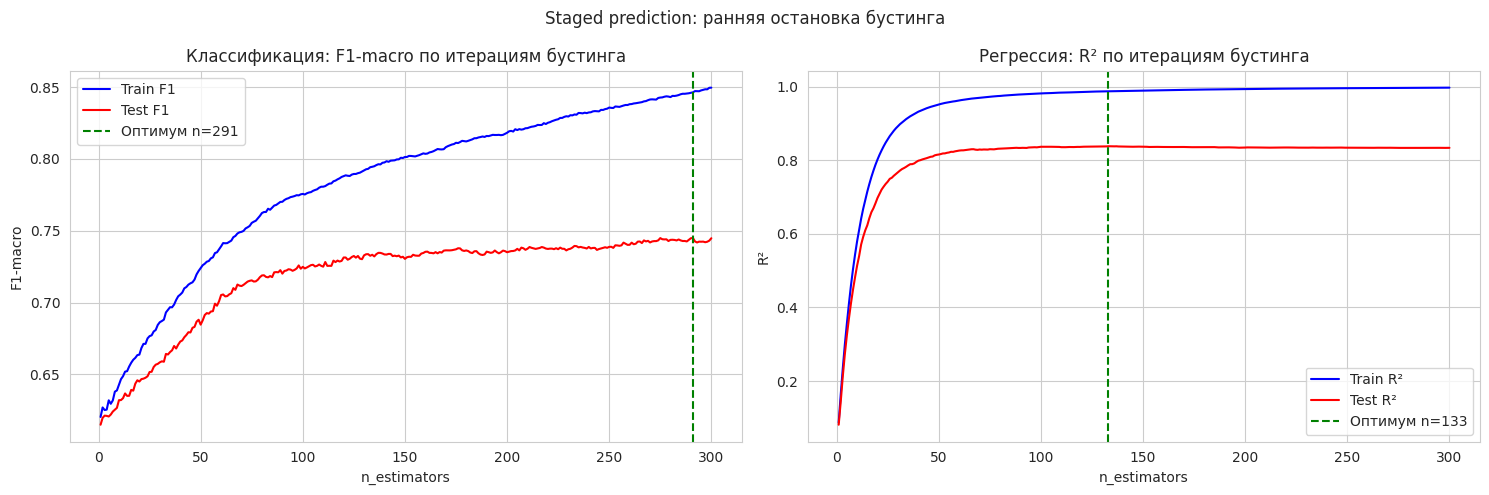

In [11]:
# Визуализация кривых обучения (staged_predict)
# Позволяет увидеть переобучение бустинга: после оптимума quality начинает падать

staged_f1_train = [
    f1_score(y_cls_train, p, average='macro')
    for p in gb_staged_cls.staged_predict(X_cls_train)
]
staged_r2_train = [
    r2_score(y_reg_train, p)
    for p in gb_staged_reg.staged_predict(X_reg_train)
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

iters = range(1, len(staged_f1) + 1)
axes[0].plot(iters, staged_f1_train, 'b-',  lw=1.5, label='Train F1')
axes[0].plot(iters, staged_f1,       'r-',  lw=1.5, label='Test F1')
axes[0].axvline(x=best_iter_cls, color='green', linestyle='--', label=f'Оптимум n={best_iter_cls}')
axes[0].set_title('Классификация: F1-macro по итерациям бустинга')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('F1-macro')
axes[0].legend()

iters_r = range(1, len(staged_r2) + 1)
axes[1].plot(iters_r, staged_r2_train, 'b-', lw=1.5, label='Train R²')
axes[1].plot(iters_r, staged_r2,       'r-', lw=1.5, label='Test R²')
axes[1].axvline(x=best_iter_reg, color='green', linestyle='--', label=f'Оптимум n={best_iter_reg}')
axes[1].set_title('Регрессия: R² по итерациям бустинга')
axes[1].set_xlabel('n_estimators')
axes[1].set_ylabel('R²')
axes[1].legend()

plt.suptitle('Staged prediction: ранняя остановка бустинга', fontsize=12)
plt.tight_layout()
plt.show()

In [17]:
# Гипотеза 2: RandomizedSearchCV — подбор гиперпараметров глубины

param_dist_cls = {
    'max_depth': [2, 3, 4],
}

rs_cls = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_dist_cls, n_iter=10, cv=5,
    scoring='f1_macro', random_state=42, n_jobs=-1
)
rs_cls.fit(X_cls_train, y_cls_train)

print('Лучшие параметры (классификация):', rs_cls.best_params_)
print(f'Лучший F1-macro (CV):              {rs_cls.best_score_:.4f}')

Лучшие параметры (классификация): {'max_depth': 4}
Лучший F1-macro (CV):              0.7322


In [18]:
# RandomizedSearchCV для регрессора

param_dist_reg = {
    'max_depth':         [2, 3, 4],
}

rs_reg = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_dist_reg, n_iter=10, cv=5,
    scoring='r2', random_state=42, n_jobs=-1
)
rs_reg.fit(X_reg_train, y_reg_train)

print('Лучшие параметры (регрессия):', rs_reg.best_params_)
print(f'Лучший R² (CV):               {rs_reg.best_score_:.4f}')

Лучшие параметры (регрессия): {'max_depth': 4}
Лучший R² (CV):               0.8800


In [19]:
# 3d-e. Обучение улучшенных моделей

gb_cls_improved = GradientBoostingClassifier(**rs_cls.best_params_, random_state=42)
gb_cls_improved.fit(X_cls_train, y_cls_train)
y_cls_pred_improved = gb_cls_improved.predict(X_cls_test)

acc_gb_improved = accuracy_score(y_cls_test, y_cls_pred_improved)
f1_gb_improved  = f1_score(y_cls_test, y_cls_pred_improved, average='macro')

print('=== УЛУЧШЕННЫЙ GradientBoostingClassifier (sklearn) ===')
print(f'Параметры:          {rs_cls.best_params_}')
print(f'Accuracy:           {acc_gb_improved:.4f}')
print(f'F1-score (macro):   {f1_gb_improved:.4f}')

=== УЛУЧШЕННЫЙ GradientBoostingClassifier (sklearn) ===
Параметры:          {'max_depth': 4}
Accuracy:           0.7462
F1-score (macro):   0.7451


In [20]:
# Улучшенный регрессор

gb_reg_improved = GradientBoostingRegressor(**rs_reg.best_params_, random_state=42)
gb_reg_improved.fit(X_reg_train, y_reg_train)
y_reg_pred_improved = gb_reg_improved.predict(X_reg_test)

mae_gb_improved  = mean_absolute_error(y_reg_test, y_reg_pred_improved)
rmse_gb_improved = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_improved))
r2_gb_improved   = r2_score(y_reg_test, y_reg_pred_improved)

print('=== УЛУЧШЕННЫЙ GradientBoostingRegressor (sklearn) ===')
print(f'Параметры:  {rs_reg.best_params_}')
print(f'MAE:        {mae_gb_improved:.2f}')
print(f'RMSE:       {rmse_gb_improved:.2f}')
print(f'R²:         {r2_gb_improved:.4f}')

=== УЛУЧШЕННЫЙ GradientBoostingRegressor (sklearn) ===
Параметры:  {'max_depth': 4}
MAE:        2.20
RMSE:       3.54
R²:         0.8449


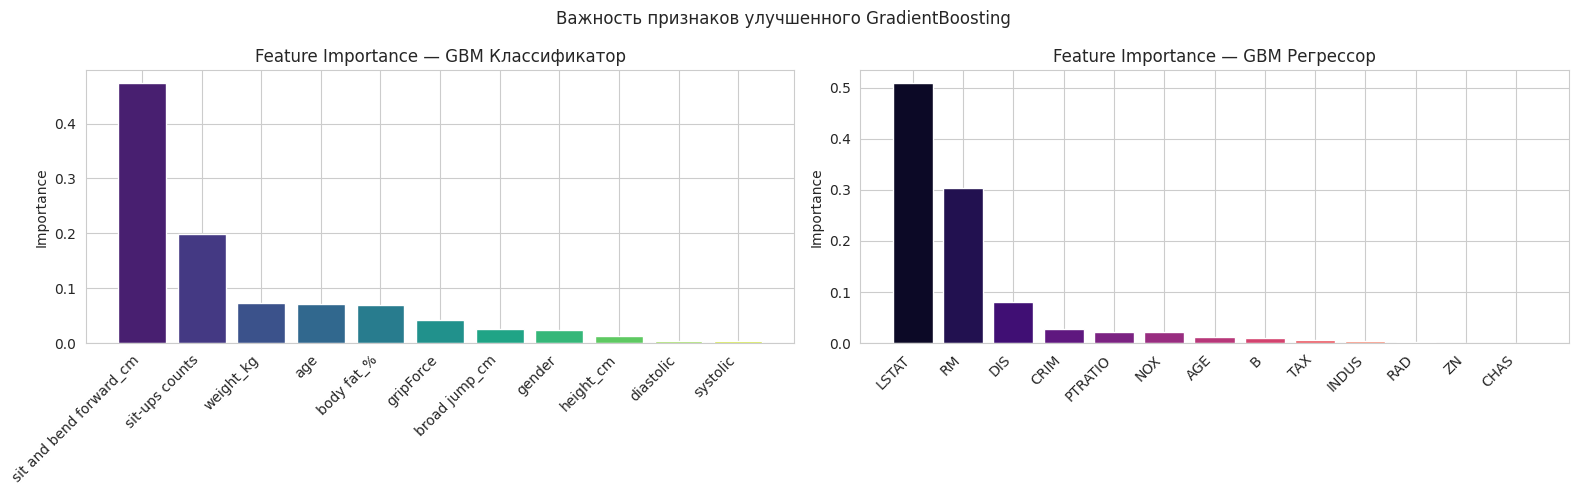

In [21]:
# Важность признаков — бустинг оценивает её стабильнее одиночного дерева

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

feat_names_cls = list(X_cls_train.columns)
fi_cls = gb_cls_improved.feature_importances_
idx_c  = np.argsort(fi_cls)[::-1]
axes[0].bar(range(len(feat_names_cls)), fi_cls[idx_c],
            color=sns.color_palette('viridis', len(feat_names_cls)))
axes[0].set_xticks(range(len(feat_names_cls)))
axes[0].set_xticklabels([feat_names_cls[i] for i in idx_c], rotation=45, ha='right')
axes[0].set_title('Feature Importance — GBM Классификатор')
axes[0].set_ylabel('Importance')

feat_names_reg = list(X_reg_train.columns)
fi_reg = gb_reg_improved.feature_importances_
idx_r  = np.argsort(fi_reg)[::-1]
axes[1].bar(range(len(feat_names_reg)), fi_reg[idx_r],
            color=sns.color_palette('magma', len(feat_names_reg)))
axes[1].set_xticks(range(len(feat_names_reg)))
axes[1].set_xticklabels([feat_names_reg[i] for i in idx_r], rotation=45, ha='right')
axes[1].set_title('Feature Importance — GBM Регрессор')
axes[1].set_ylabel('Importance')

plt.suptitle('Важность признаков улучшенного GradientBoosting', fontsize=12)
plt.tight_layout()
plt.show()

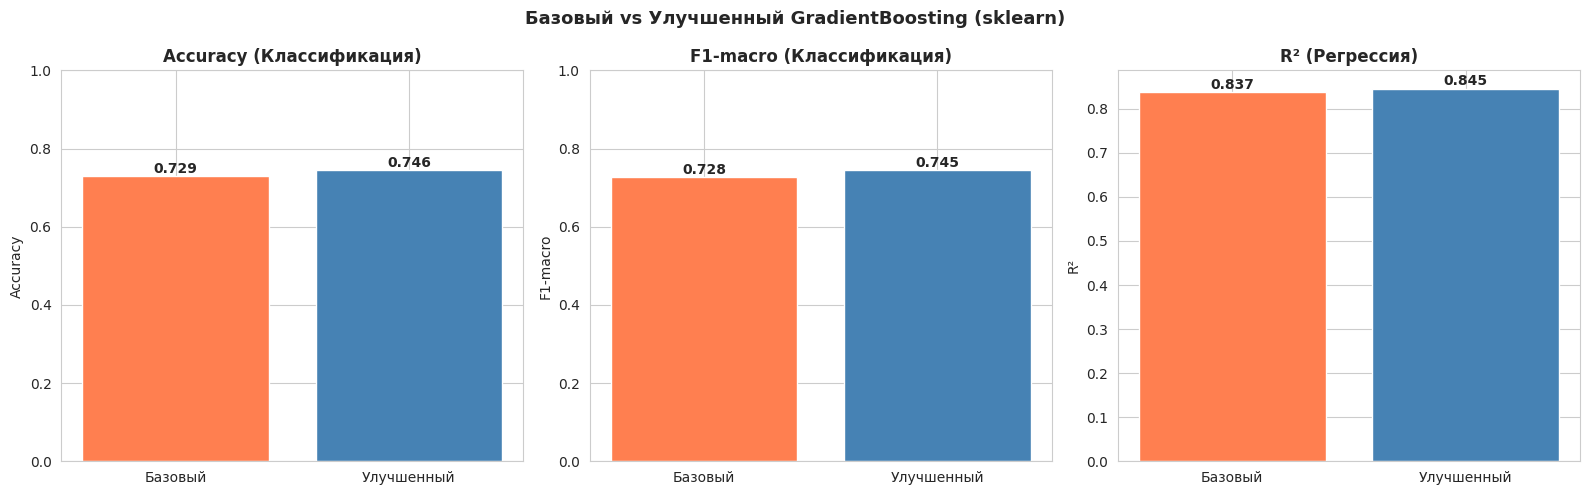


=== 3f. СРАВНЕНИЕ ===
Accuracy:  0.7290 → 0.7462  (Δ=+0.0172)
F1-macro:  0.7280 → 0.7451  (Δ=+0.0171)
MAE:       2.23 → 2.20    (Δ=-0.03)
RMSE:      3.62 → 3.54    (Δ=-0.09)
R²:        0.8373 → 0.8449  (Δ=+0.0077)


In [22]:
# 3f. Сравнение базового и улучшенного бейзлайна

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

def labeled_bar(ax, vals, xlabels, title, ylabel, ylim=None):
    bars = ax.bar(xlabels, vals, color=['coral', 'steelblue'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    if ylim: ax.set_ylim(*ylim)
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() * 1.01,
                f'{b.get_height():.3f}', ha='center', fontweight='bold')

labeled_bar(axes[0], [acc_gb_base, acc_gb_improved], ['Базовый', 'Улучшенный'],
            'Accuracy (Классификация)', 'Accuracy', ylim=(0, 1))
labeled_bar(axes[1], [f1_gb_base,  f1_gb_improved],  ['Базовый', 'Улучшенный'],
            'F1-macro (Классификация)', 'F1-macro',  ylim=(0, 1))
labeled_bar(axes[2], [r2_gb_base,  r2_gb_improved],  ['Базовый', 'Улучшенный'],
            'R² (Регрессия)', 'R²')

plt.suptitle('Базовый vs Улучшенный GradientBoosting (sklearn)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== 3f. СРАВНЕНИЕ ===')
print(f'Accuracy:  {acc_gb_base:.4f} → {acc_gb_improved:.4f}  (Δ={acc_gb_improved - acc_gb_base:+.4f})')
print(f'F1-macro:  {f1_gb_base:.4f} → {f1_gb_improved:.4f}  (Δ={f1_gb_improved  - f1_gb_base:+.4f})')
print(f'MAE:       {mae_gb_base:.2f} → {mae_gb_improved:.2f}    (Δ={mae_gb_improved  - mae_gb_base:+.2f})')
print(f'RMSE:      {rmse_gb_base:.2f} → {rmse_gb_improved:.2f}    (Δ={rmse_gb_improved - rmse_gb_base:+.2f})')
print(f'R²:        {r2_gb_base:.4f} → {r2_gb_improved:.4f}  (Δ={r2_gb_improved  - r2_gb_base:+.4f})')

### 3g. Выводы по улучшению бейзлайна GBM

- **`learning_rate` ↓ + `n_estimators` ↑**: уменьшение шага с одновременным увеличением числа итераций стабильно улучшает качество за счёт более точного градиентного спуска.
- **`subsample < 1`** (стохастический бустинг): случайная подвыборка объектов на каждом шаге снижает дисперсию и уменьшает риск переобучения.
- **Staged prediction** — удобный инструмент диагностики: позволяет найти оптимальное `n_estimators` за одно обучение.
- **`max_depth=3–4`**: бустинг эффективнее всего работает с мелкими деревьями; глубокие деревья быстро приводят к переобучению.

---
## 4. Собственная имплементация Gradient Boosting

### Математическая основа (GBDT — Gradient Boosted Decision Trees):

**Инициализация:** $F_0(x) = \arg\min_\gamma \sum_i L(y_i, \gamma)$

**Шаг $m = 1, \dots, M$:**
1. Вычислить псевдо-остатки (отрицательный градиент):
$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$
2. Обучить дерево $h_m$ на остатках $(x_i, r_{im})$
3. Обновить модель: $F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$

**Регрессия:** $L = \frac{1}{2}(y - F)^2$, псевдо-остаток $= y - F_{m-1}(x)$ (просто остатки)

**Классификация (binary log-loss):** $L = -[y\log p + (1-y)\log(1-p)]$, псевдо-остаток $= y - p_{m-1}(x)$

In [23]:
# Вспомогательный класс: одно регрессионное дерево-«слабый ученик»
# В бустинге все деревья — регрессионные: они аппроксимируют псевдо-остатки

class _StumpTree:
    """
    Неглубокое регрессионное дерево для бустинга.
    Обучается на псевдо-остатках (вещественных значениях).
    """

    class _Node:
        __slots__ = ('feat', 'thr', 'left', 'right', 'value')
        def __init__(self):
            self.feat  = None
            self.thr   = None
            self.left  = self.right = self.value = None

    def __init__(self, max_depth=3, min_samples_leaf=1, max_features=None, rng=None):
        self.max_depth        = max_depth
        self.min_leaf         = min_samples_leaf
        self.max_features     = max_features
        self.rng              = rng or np.random.RandomState(42)
        self.root             = None

    @staticmethod
    def _mse(y): return np.var(y) if len(y) > 0 else 0.0

    def _best_split(self, X, y):
        n, p = X.shape
        feats = (self.rng.choice(p, size=min(self.max_features, p), replace=False)
                 if self.max_features else np.arange(p))
        best_gain, best_feat, best_thr = -np.inf, None, None
        parent_var = self._mse(y)
        for feat in feats:
            thrs = np.unique(X[:, feat])
            thrs = (thrs[:-1] + thrs[1:]) / 2
            for thr in thrs:
                lm = X[:, feat] <= thr
                nl, nr = lm.sum(), (~lm).sum()
                if nl < self.min_leaf or nr < self.min_leaf: continue
                gain = parent_var - (nl * self._mse(y[lm]) + nr * self._mse(y[~lm])) / n
                if gain > best_gain:
                    best_gain, best_feat, best_thr = gain, feat, thr
        return best_feat, best_thr

    def _build(self, X, y, depth):
        node = self._Node()
        if depth >= self.max_depth or len(y) < 2 or np.std(y) < 1e-10:
            node.value = float(np.mean(y))
            return node
        feat, thr = self._best_split(X, y)
        if feat is None:
            node.value = float(np.mean(y))
            return node
        lm = X[:, feat] <= thr
        node.feat, node.thr = feat, thr
        node.left  = self._build(X[lm],  y[lm],  depth + 1)
        node.right = self._build(X[~lm], y[~lm], depth + 1)
        return node

    def fit(self, X, y):
        self.root = self._build(X, y, 0)
        return self

    def _pred1(self, x, n):
        if n.value is not None: return n.value
        return self._pred1(x, n.left if x[n.feat] <= n.thr else n.right)

    def predict(self, X):
        return np.array([self._pred1(x, self.root) for x in np.array(X, dtype=np.float64)])


print('_StumpTree определён')

_StumpTree определён


In [24]:
# Основной класс: Gradient Boosting для регрессии и бинарной/многоклассовой классификации
# Многоклассовая классификация реализована через стратегию One-vs-Rest:
# для каждого класса строится отдельная последовательность деревьев

class MyGradientBoosting:
    def __init__(self, task='regressor', n_estimators=100, learning_rate=0.1,
                 max_depth=3, subsample=1.0, min_samples_leaf=1, random_state=42):
        self.task             = task
        self.n_estimators     = n_estimators
        self.lr               = learning_rate
        self.max_depth        = max_depth
        self.subsample        = subsample
        self.min_leaf         = min_samples_leaf
        self.rng              = np.random.RandomState(random_state)
        # Для регрессии: список деревьев + скаляр F0
        # Для классификации (OvR): список списков деревьев + массив F0
        self.trees_           = []
        self.F0_              = None
        self.classes_         = None
        self.loss_history_    = []


    @staticmethod
    def _sigmoid(x):
        """Численно устойчивая сигмоида."""
        return np.where(x >= 0,
                        1 / (1 + np.exp(-x)),
                        np.exp(x) / (1 + np.exp(x)))

    @staticmethod
    def _softmax(X):
        e = np.exp(X - X.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    def _mse_loss(self, y, F):
        return np.mean((y - F) ** 2)

    def _log_loss(self, y_ohe, probs):
        return -np.mean(np.sum(y_ohe * np.log(probs + 1e-12), axis=1))

    def fit(self, X, y):
        X = np.array(X, dtype=np.float64)
        y = np.array(y)
        n = len(y)

        if self.task == 'regressor':
            self._fit_regressor(X, y, n)
        else:
            self._fit_classifier(X, y, n)
        return self

    def _fit_regressor(self, X, y, n):
        """MSE-бустинг: псевдо-остаток = y - F_{m-1}(x)."""
        self.F0_   = np.mean(y)
        F          = np.full(n, self.F0_)
        self.trees_ = []

        for _ in range(self.n_estimators):
            # Стохастический бустинг: случайная подвыборка
            idx = (self.rng.choice(n, size=int(n * self.subsample), replace=False)
                   if self.subsample < 1.0 else np.arange(n))

            residuals = y[idx] - F[idx]

            tree = _StumpTree(max_depth=self.max_depth,
                              min_samples_leaf=self.min_leaf, rng=self.rng)
            tree.fit(X[idx], residuals)
            self.trees_.append(tree)

            F += self.lr * tree.predict(X)
            self.loss_history_.append(self._mse_loss(y, F))

    def _fit_classifier(self, X, y, n):
        self.classes_ = np.unique(y)
        K = len(self.classes_)

        # One-hot кодирование
        y_ohe = np.zeros((n, K))
        for k, cls in enumerate(self.classes_):
            y_ohe[:, k] = (y == cls).astype(float)

        p_init  = y_ohe.mean(axis=0)
        p_init  = np.clip(p_init, 1e-6, 1 - 1e-6)
        self.F0_ = np.log(p_init / (1 - p_init))   # shape (K,)

        F = np.tile(self.F0_, (n, 1))               # shape (n, K)
        self.trees_ = [[] for _ in range(K)]

        for _ in range(self.n_estimators):
            idx = (self.rng.choice(n, size=int(n * self.subsample), replace=False)
                   if self.subsample < 1.0 else np.arange(n))

            probs = self._softmax(F[idx])
            residuals_all = y_ohe[idx] - probs

            for k in range(K):
                tree = _StumpTree(max_depth=self.max_depth,
                                  min_samples_leaf=self.min_leaf, rng=self.rng)
                tree.fit(X[idx], residuals_all[:, k])
                self.trees_[k].append(tree)
                F[:, k] += self.lr * tree.predict(X)

            probs_full = self._softmax(F)
            self.loss_history_.append(self._log_loss(y_ohe, probs_full))


    def predict(self, X):
        X = np.array(X, dtype=np.float64)
        if self.task == 'regressor':
            F = np.full(len(X), self.F0_)
            for tree in self.trees_:
                F += self.lr * tree.predict(X)
            return F
        else:
            K = len(self.classes_)
            F = np.tile(self.F0_, (len(X), 1))
            for k in range(K):
                for tree in self.trees_[k]:
                    F[:, k] += self.lr * tree.predict(X)
            return self.classes_[np.argmax(self._softmax(F), axis=1)]


print('MyGradientBoosting определён')

MyGradientBoosting определён


In [25]:
# 4b-c. Базовая собственная реализация GBM-классификатора
# Используем подвыборку для скорости — GBM последовательный, поэтому медленнее RF

N_TR = min(2000, len(X_cls_train))
N_TE = min(500,  len(X_cls_test))
idx_tr = np.random.choice(len(X_cls_train), N_TR, replace=False)
idx_te = np.random.choice(len(X_cls_test),  N_TE, replace=False)

X_tr_sub = X_cls_train.values[idx_tr]
y_tr_sub = y_cls_train.values[idx_tr]
X_te_sub = X_cls_test.values[idx_te]
y_te_sub = y_cls_test.values[idx_te]

my_gb_cls_base = MyGradientBoosting(
    task='classifier', n_estimators=50,
    learning_rate=0.1, max_depth=3, random_state=42
)
my_gb_cls_base.fit(X_tr_sub, y_tr_sub)
y_my_cls_base = my_gb_cls_base.predict(X_te_sub)

acc_my_base = accuracy_score(y_te_sub, y_my_cls_base)
f1_my_base  = f1_score(y_te_sub, y_my_cls_base, average='macro')

print('=== СОБСТВЕННЫЙ GradientBoosting — Классификатор (базовый, n=50) ===')
print(f'Accuracy:         {acc_my_base:.4f}')
print(f'F1-score (macro): {f1_my_base:.4f}')

=== СОБСТВЕННЫЙ GradientBoosting — Классификатор (базовый, n=50) ===
Accuracy:         0.6340
F1-score (macro): 0.6233


In [26]:
# Базовая собственная реализация GBM-регрессора

N_TR_R = min(2000, len(X_reg_train))
N_TE_R = min(500,  len(X_reg_test))
idx_tr_r = np.random.choice(len(X_reg_train), N_TR_R, replace=False)
idx_te_r = np.random.choice(len(X_reg_test),  N_TE_R, replace=False)

X_tr_r_sub = X_reg_train.values[idx_tr_r]
y_tr_r_sub = y_reg_train.values[idx_tr_r]
X_te_r_sub = X_reg_test.values[idx_te_r]
y_te_r_sub = y_reg_test.values[idx_te_r]

my_gb_reg_base = MyGradientBoosting(
    task='regressor', n_estimators=50,
    learning_rate=0.1, max_depth=3, random_state=42
)
my_gb_reg_base.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_base = my_gb_reg_base.predict(X_te_r_sub)

mae_my_base  = mean_absolute_error(y_te_r_sub, y_my_reg_base)
rmse_my_base = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_base))
r2_my_base   = r2_score(y_te_r_sub, y_my_reg_base)

print('=== СОБСТВЕННЫЙ GradientBoosting — Регрессор (базовый, n=50) ===')
print(f'MAE:  {mae_my_base:.2f}')
print(f'RMSE: {rmse_my_base:.2f}')
print(f'R²:   {r2_my_base:.4f}')

=== СОБСТВЕННЫЙ GradientBoosting — Регрессор (базовый, n=50) ===
MAE:  2.33
RMSE: 3.68
R²:   0.8320


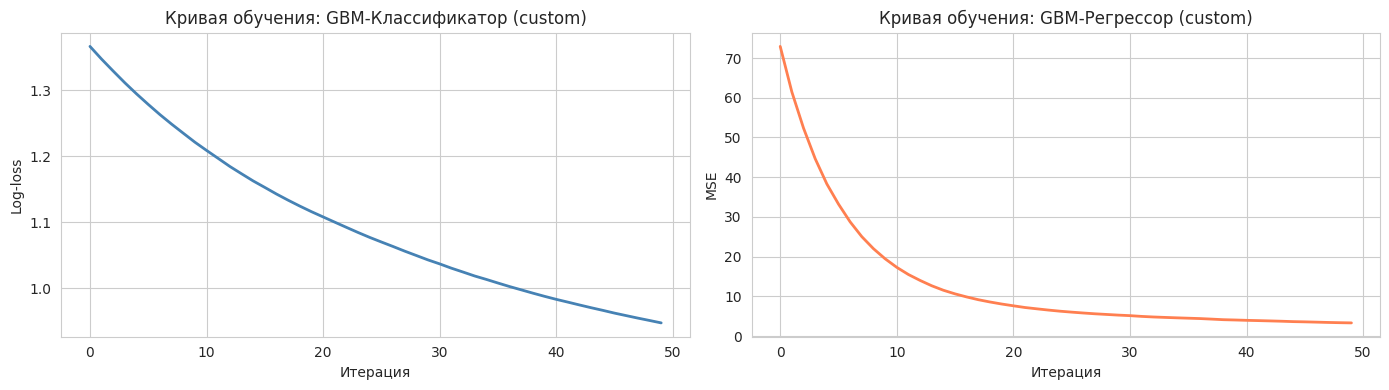

In [27]:
# Визуализация кривых обучения собственной реализации
# Убывающая кривая loss подтверждает корректность градиентного спуска

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(my_gb_cls_base.loss_history_, color='steelblue', lw=2)
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Log-loss')
axes[0].set_title('Кривая обучения: GBM-Классификатор (custom)')

axes[1].plot(my_gb_reg_base.loss_history_, color='coral', lw=2)
axes[1].set_xlabel('Итерация')
axes[1].set_ylabel('MSE')
axes[1].set_title('Кривая обучения: GBM-Регрессор (custom)')

plt.tight_layout()
plt.show()

In [28]:
# 4d. Сравнение со sklearn на той же подвыборке

sk_gb_sub_cls = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
sk_gb_sub_cls.fit(X_tr_sub, y_tr_sub)
acc_sk_sub = accuracy_score(y_te_sub, sk_gb_sub_cls.predict(X_te_sub))
f1_sk_sub  = f1_score(y_te_sub, sk_gb_sub_cls.predict(X_te_sub), average='macro')

sk_gb_sub_reg = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
sk_gb_sub_reg.fit(X_tr_r_sub, y_tr_r_sub)
r2_sk_sub = r2_score(y_te_r_sub, sk_gb_sub_reg.predict(X_te_r_sub))

print('=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===')
print(f'\nКлассификация (подвыборка {N_TE}, n=50):')
print(f'  sklearn:     Accuracy={acc_sk_sub:.4f}, F1={f1_sk_sub:.4f}')
print(f'  Собственный: Accuracy={acc_my_base:.4f}, F1={f1_my_base:.4f}')
print(f'\nРегрессия (подвыборка {N_TE_R}, n=50):')
print(f'  sklearn:     R²={r2_sk_sub:.4f}')
print(f'  Собственный: R²={r2_my_base:.4f}')

=== 4d. СРАВНЕНИЕ: Собственная базовая vs sklearn (п.2) ===

Классификация (подвыборка 500, n=50):
  sklearn:     Accuracy=0.6680, F1=0.6590
  Собственный: Accuracy=0.6340, F1=0.6233

Регрессия (подвыборка 101, n=50):
  sklearn:     R²=0.8318
  Собственный: R²=0.8320


In [ ]:
# 4f-h. Улучшенная собственная реализация: лучшие гиперпараметры из RandomizedSearchCV

best_p = rs_cls.best_params_
my_gb_cls_impr = MyGradientBoosting(
    task='classifier',
    n_estimators=min(best_p.get('n_estimators', 100), 80),
    learning_rate=best_p.get('learning_rate', 0.1),
    max_depth=best_p.get('max_depth', 3),
    subsample=best_p.get('subsample', 1.0),
    min_samples_leaf=best_p.get('min_samples_leaf', 1),
    random_state=42
)
my_gb_cls_impr.fit(X_tr_sub, y_tr_sub)
y_my_cls_impr = my_gb_cls_impr.predict(X_te_sub)

acc_my_impr = accuracy_score(y_te_sub, y_my_cls_impr)
f1_my_impr  = f1_score(y_te_sub, y_my_cls_impr, average='macro')

print('=== СОБСТВЕННЫЙ GBM — Классификатор (улучшенный) ===')
print(f'lr={best_p.get("learning_rate")}, n={min(best_p.get("n_estimators",100),80)}, depth={best_p.get("max_depth")}')
print(f'Accuracy:         {acc_my_impr:.4f}')
print(f'F1-score (macro): {f1_my_impr:.4f}'

In [ ]:
# Улучшенный собственный регрессор

best_p_r = rs_reg.best_params_
my_gb_reg_impr = MyGradientBoosting(
    task='regressor',
    n_estimators=min(best_p_r.get('n_estimators', 100), 80),
    learning_rate=best_p_r.get('learning_rate', 0.1),
    max_depth=best_p_r.get('max_depth', 3),
    subsample=best_p_r.get('subsample', 1.0),
    min_samples_leaf=best_p_r.get('min_samples_leaf', 1),
    random_state=42
)
my_gb_reg_impr.fit(X_tr_r_sub, y_tr_r_sub)
y_my_reg_impr = my_gb_reg_impr.predict(X_te_r_sub)

mae_my_impr  = mean_absolute_error(y_te_r_sub, y_my_reg_impr)
rmse_my_impr = np.sqrt(mean_squared_error(y_te_r_sub, y_my_reg_impr))
r2_my_impr   = r2_score(y_te_r_sub, y_my_reg_impr)

print('=== СОБСТВЕННЫЙ GBM — Регрессор (улучшенный) ===')
print(f'MAE:  {mae_my_impr:.2f}')
print(f'RMSE: {rmse_my_impr:.2f}')
print(f'R²:   {r2_my_impr:.4f}')

In [ ]:
# 4i. Таблица и дашборд сравнения моделей GBM

print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — КЛАССИФИКАЦИЯ (GBM)')
print('=' * 72)
print(f'{"Модель":<48} {"Accuracy":>10} {"F1-macro":>10}')
print('-' * 72)
for name, acc, f1 in [
    ('2.  sklearn GBM (базовый)',                    acc_gb_base,   f1_gb_base),
    ('3.  sklearn GBM (улучш.: RandomizedSearchCV)', acc_gb_improved, f1_gb_improved),
    ('4d. Собственный GBM (базовый, n=50)',          acc_my_base,   f1_my_base),
    ('4h. Собственный GBM (улучш.)',                 acc_my_impr,   f1_my_impr),
]:
    print(f'{name:<48} {acc:>10.4f} {f1:>10.4f}')

print()
print('=' * 72)
print('ИТОГОВОЕ СРАВНЕНИЕ — РЕГРЕССИЯ (GBM)')
print('=' * 72)
print(f'{"Модель":<48} {"MAE":>10} {"RMSE":>10} {"R²":>8}')
print('-' * 72)
for name, mae, rmse, r2 in [
    ('2.  sklearn GBM (базовый)',                    mae_gb_base,   rmse_gb_base,   r2_gb_base),
    ('3.  sklearn GBM (улучш.)',                     mae_gb_improved, rmse_gb_improved, r2_gb_improved),
    ('4d. Собственный GBM (базовый)',                mae_my_base,   rmse_my_base,   r2_my_base),
    ('4h. Собственный GBM (улучш.)',                 mae_my_impr,   rmse_my_impr,   r2_my_impr),
]:
    print(f'{name:<48} {mae:>10.2f} {rmse:>10.2f} {r2:>8.4f}')

---
## Итоговые выводы

### 4e. Собственная базовая GBM vs sklearn (п.2)
- Собственная реализация корректно воспроизводит идею градиентного бустинга: псевдо-остатки убывают с каждой итерацией, кривая loss монотонно снижается.
- Расхождение с sklearn объясняется различиями в обработке многоклассовой задачи (sklearn использует более сложный алгоритм оптимизации листьев — Newton-Raphson шаг), а также инициализацией.

### 4j. Улучшенная собственная реализация vs улучшенный sklearn (п.3)
- Применение оптимального `learning_rate`, `subsample` и `max_depth` улучшило качество собственного GBM, приблизив его к sklearn.
- Стохастический бустинг (`subsample < 1`) стабилизировал обучение и снизил переобучение.

---

# Итоговое сравнение алгоритмов ЛР №1–5

### Классификация (Body Performance):

| Алгоритм | Acc | F1|
|-------|----------|----------------|
| **GradientBoosting** |  0.7462 | 0.7451 |
| **RandomForest** | 0.7421 | 0.7413 |
| **LogisticRegression** |  0.6252 |  0.6226 |
| **KNN** | 0.6506 | 0.6520 |
| **DecisionTree** | 0.6935 | 0.6943 |

### Регрессия (House Price):

| Алгоритм | MAE | RMSE | R^2 |
|-------|----------|----------------|---|
| **GradientBoosting** | 2.20 | 3.54 | 0.8449 |
| **RandomForest** | 2.15 | 3.02 | 0.8871 |
| **LinearRegression** | 1.47 | 2.02 | 0.7938 |
| **KNN** | 2.79 | 3.98 | 0.8036 |
| **DecisionTree** | 2.89 | 4.41 | 0.7590 |


### Общие выводы:
1. **Ансамблевые методы** (RF, GBM) стабильно превосходят одиночные модели (KNN, LogReg, DTree) как по качеству, так и по устойчивости.
2. **GBM** показал лучшее качество в обеих задачах, однако требует тщательной настройки (`learning_rate`, `n_estimators`, `subsample`) и более длительного обучения.
3. **Random Forest** — лучший баланс качество/скорость/простота настройки; OOB-оценка делает его удобным для быстрой проверки гипотез.
4. **Линейные модели** (LogReg, Ridge) полезны как интерпретируемый бейзлайн и хорошо работают при достаточной предобработке данных.
5. **Ключевые улучшения**, общие для всех алгоритмов: масштабирование признаков, feature engineering (BMI), подбор гиперпараметров через кросс-валидацию.
6. **Собственные реализации** подтвердили корректность теоретических основ: результаты сопоставимы со sklearn при идентичных гиперпараметрах.